<a href="https://colab.research.google.com/github/Rabidhau/assessment0/blob/main/wps7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network.
## Instructions and Requirements:
This week workshop will have two sections:

*   Section: 1
  *   In this section, we will implement and observe the operations of various layers used to build the CNN.
  *   By the end of the workshop, we expect you to be able to:
      1.   Explain the Convolution operation
      2.   Explain the pooling operation
      3.   Get familiar with various hyperparameters i.e. stride, padding

*   Section: 2
  *   In this section we will compile all the learning from section 1 to build a basic Convolutional Neural Network using Keras and Tensorflow.
  

##Convolution Summary:

We convolve (slide) a small matrix also known as Filter/kernel, performing element wise matrix multiplications to produce filter-map.

  *   Objective of a convolution operations:
        1.   Apply a set of weights-a filter- to extract local features.
        2.   Use Multiple filters to extract different features.
        3.   Spatially share parameters of each filter.

Mathematically it perform following:
$$ conv(I,K)_{xy} = ∑_{i=1}^{h}\sum_{j=1}^{w}K_{ij}.I_{x+i-1,y+j-1} \tag{1} $$

Where:
- $I$ input image matrix..
-$K$ kernel/Filter used to perform convolution.

Hyper-parameters in Convolution Operations:
*   Number of Filters(K)
*   Size of Filters(F)
*   Stride(S)
*   amount of zero padding(P)

Output Dimensions is given by:

\begin{align}
\mathbf{O}  = \frac{W_{in} -f + 2p}{s} + 1 \tag{2}
\end{align}

### Exercise-1.

Perform following Convolution Operations:

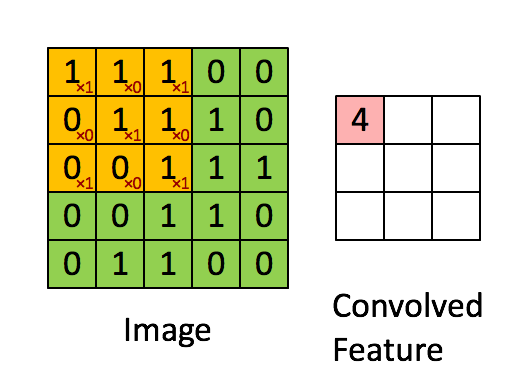

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [ ]:
# Defining the input matrix as above using np.array function.
I = np.array([[1, 1, 1, 0, 0], [0, 1, 1, 1 ,0], [0, 0, 1, 1, 1,], [0, 0, 1, 1, 0], [0, 1, 1, 0, 0]])

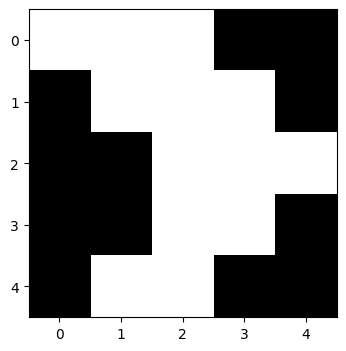

In [ ]:
# Visualizing the input.
plt.imshow(I)

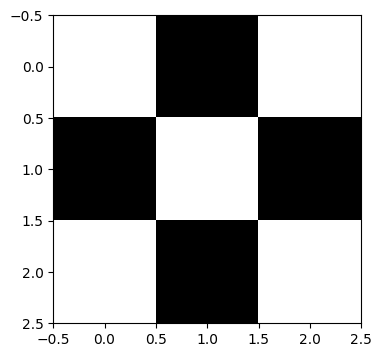

In [ ]:
# Defining the input matrix as above using np.matrix function.
K = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
# Visualizing the Filter.
plt.imshow(K)


In [ ]:
def convolution(img, filter):
  """
  Function performs convolution operations.
  Arguments:
  Inputs Arguments:
  img(nd array): numpy array of an input image.
  filter(nd array): numpy array of an input filter.
  Output Argumets:
  Filter_Map of Dimesions specified by eq(2).
  """
  output_dimension = img.shape[0] - filter.shape[0] + 2
  filter_map = np.zeros(shape=(output_dimension, output_dimension))


  return filter_map


In [ ]:
img = convolution(I, K)

In [ ]:
assert img.shape == (3, 3), " Convolution Operation did not produce correct output"

AssertionError:  Convolution Operation did not produce correct output

Test Passed


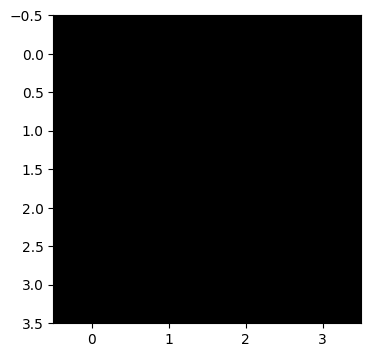

In [ ]:
plt.imshow(img)
print("Test Passed")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Ai/Train.zip','r') as zip_ref:
  zip_ref.extractall('/content/drive/MyDrive/assignment_0')

In [ ]:

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Copy of FruitinAmazon.zip','r') as zip_ref:
  zip_ref.extractall('/content/drive/MyDrive/Ai')

# Section-2: In this section we will build very basic CNN architecture, Compile and train our CNN model.

This will be further divided into following sections:


## Section-2.1: Data Pre-processing.

Expected structure of folder:

-/Datasets/

      --train/
        -- acai/....     
        -- cupuacu/---
        -- all the classes--

In [ ]:
data_dir = "/content/drive/MyDrive/Ai/FruitinAmazon/train"

In [ ]:
data_dir = "/content/drive/MyDrive/assignment_0/Train"

In [ ]:
import os
from PIL import Image

data_dir = "/content/drive/MyDrive/assignment_0/Train"
corrupted_images = []

# Walk through all files in the directory
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                img.verify()  # This will raise an exception for corrupt images
        except (IOError, SyntaxError) as e:
            print(f"Corrupted image: {file_path} - Error: {e}")
            corrupted_images.append(file_path)

print(f"\nTotal corrupted images found: {len(corrupted_images)}")



Total corrupted images found: 0


In [ ]:
import os

for path in corrupted_images:
    try:
        os.remove(path)
        print(f"Deleted: {path}")
    except Exception as e:
        print(f"Failed to delete {path}: {e}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
# Hyper-parameters:
batch_size = 32
img_height = 180
img_width = 180

### Load the Data:

We will use tf.keras.utility to load the image, for this function to work, your data should be in the structure suggested above.

We will do this for both training and validation dataset.

### Exercise:

1. To train a deep learning model we need to create a data pipeline, Multiple different approaches are available within keras framework;
one such framework is
  "tf.keras.utils.image_dataset_from_directory("parameter")

Implement above framework and explain the parameters you have used in the comment.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training"
)

Found 10792 files belonging to 38 classes.
Using 8634 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation"
)


Found 10792 files belonging to 38 classes.
Using 2158 files for validation.


In [ ]:
# Printing out number of Classes
class_names = train_ds.class_names
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']


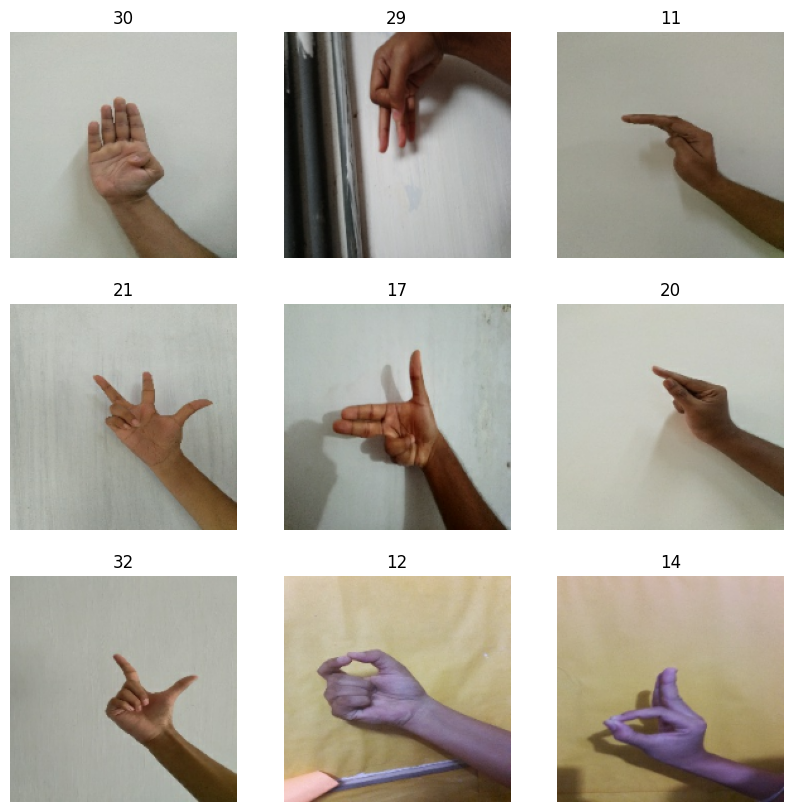

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

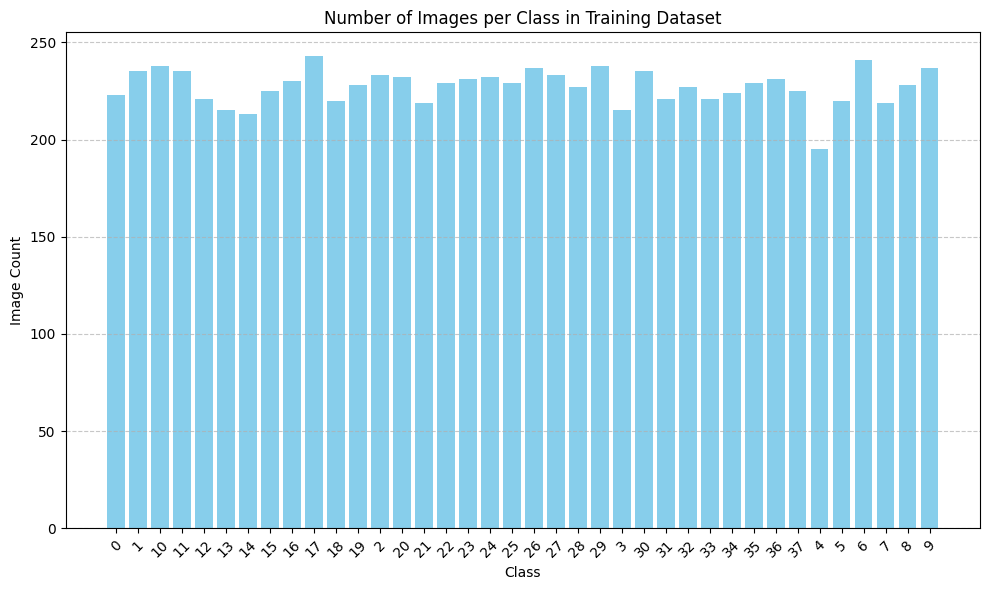

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
class_names = train_ds.class_names

# Count labels in the training dataset
label_counter = Counter()

for images, labels in train_ds:
    labels = labels.numpy()
    label_counter.update(labels)

# Convert to list of counts per class
counts = [label_counter[i] for i in range(len(class_names))]

# Plotting the bar graph
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts, color="skyblue")
plt.title("Number of Images per Class in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


## Design CNN Architecture:

For this task, we will build a CNN with following layers:

Feature-Extraction and Convolution Operations.
1.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
2.   Pooling layer[max, F=(2,2), S=2].
3.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
4.   Pooling layer[max, F=(2,2), S=2].

Classification-Assigning a class probabilities to each classes.
1.   Flatten Layer()
2.   Hidden/Dense Layer [number of neurons=128].
3.   Output Layer [number of neurons=num_classes].


### Exercise:

Please fill the hyper-parameters as defined above in the below layers.

In [ ]:
data_agumentation=keras.Sequential([

  ])

In [ ]:

def generate_model(image_height, image_width, nchannels, num_classes):
  """
  This function will generate a model with set of hyperparameters defined above.
  Input Args:
  image_height[int] = Height of an image.
  image_width[int] = Width of an image.
  nchannels[int] = Number of channels in image.
  num_classes[int] = Number of classes in dataset.
  Output Args:
  model-> A CNN model.
  """
  model = tf.keras.Sequential([
      layers.RandomFlip("horizontal",input_shape=(image_height,image_width,nchannels)),
      layers.RandomRotation(0.1,input_shape=(image_height,image_width,nchannels)),
      # Rescaling and input layer, [For keras the input shape must be(image height, image width, channels)]
      layers.Rescaling(1./255, input_shape=(image_height,image_width,nchannels)),
      # First Block of Convolution and Pooling Operations.
      layers.Conv2D(16, (3,3), padding='same', activation='relu'),
      layers.MaxPooling2D((2, 2)),
      # Second Block of Convolution and Pooling Operations.
      layers.Conv2D(16, (3,3), padding='same', activation='relu'),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.5),
      # Fully connected classifier.
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model

img_height = 180
img_width = 180

In [ ]:
num_classes = len(class_names)
model = generate_model(img_height, img_width, 3, num_classes)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_13 (RandomFlip)          │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_13 (RandomRotation)  │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_16 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 90, 90, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_16 (Flatten)                 │ (None, 32400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 128)                 │       4,147,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,150,870 (15.83 MB)

 Trainable params: 4,150,870 (15.83 MB)

 Non-trainable params: 0 (0.00 B)

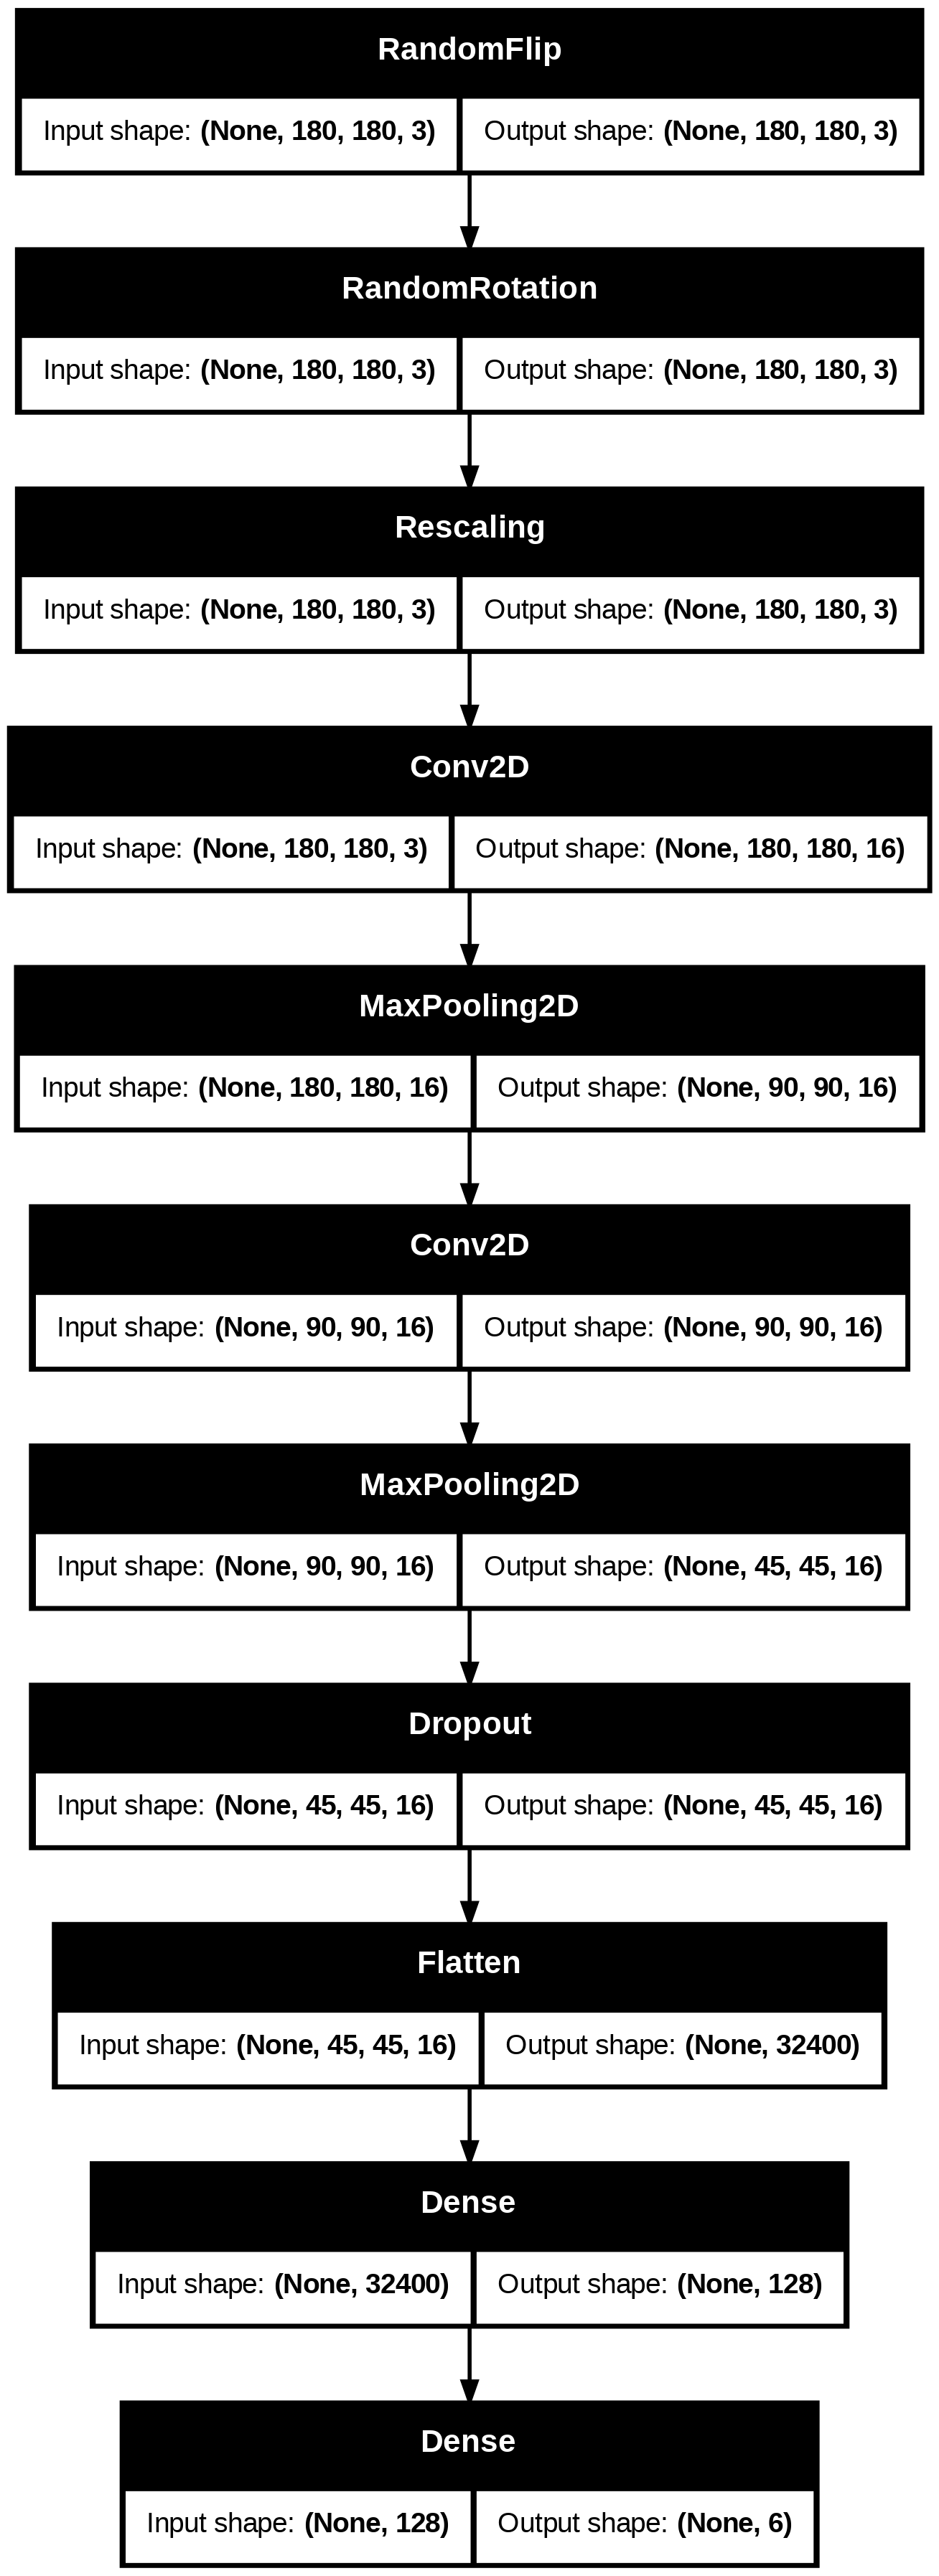

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

## Compile and Train Model.

Once we built the model, we need to compile the model before we start training.

In Model compilation, we do the following:
*   Checks for format Error.
*   Defines the loss function.
*   Defines the optimizer.
*   Defines the learning rate.
*   Defines the metrics we will be using.

For training our model we will be using:
*   loss --> SparseCategoricalCrossEntropy.
*   Optimizer --> Adam.
*   Evaluation Metric --> Accuracy.


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


### Train the Model.

For training a model with all the given hyper-parameters, and argumets we invoke fit methods.

It is a standard practise to return and hold record of losses values and metric values during training in variablel-history.

In [ ]:
epochs=10
callback=keras.callbacks.EarlyStopping(monitor="val_loss",patience=3)
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[callback])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 785ms/step - accuracy: 0.2509 - loss: 1.9786 - val_accuracy: 0.2222 - val_loss: 1.7175
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 937ms/step - accuracy: 0.2960 - loss: 1.6939 - val_accuracy: 0.2778 - val_loss: 1.6225
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3073 - loss: 1.6053 - val_accuracy: 0.3889 - val_loss: 1.5412
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 680ms/step - accuracy: 0.4800 - loss: 1.4044 - val_accuracy: 0.3333 - val_loss: 1.5019
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 637ms/step - accuracy: 0.6376 - loss: 1.1986 - val_accuracy: 0.4444 - val_loss: 1.4928
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 674ms/step - accuracy: 0.6949 - loss: 1.0807 - val_accuracy: 0.4444 - val_loss: 1.5062
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 921ms/step - accuracy: 0.6350 - loss: 0.9451 - val_accuracy: 0.5000 - val_loss: 1.3940
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 589ms/step - accuracy: 0.6988 - loss: 0.7964 - val_accuracy: 0.5556 - val_loss: 1.

## Observe the Model Performance.


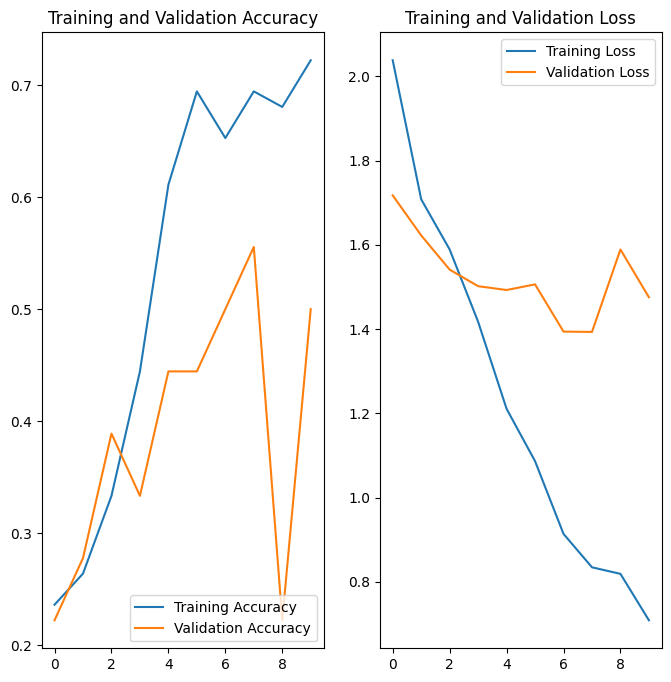

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Home Task:

Create a Test Set and Perform a model evaluation to find the test accuracy.

Based on last week built a function which predicts input examples, and also plot the result.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Ai/FruitinAmazon/test",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training"
)

Found 30 files belonging to 6 classes.
Using 24 files for training.


In [ ]:
val1_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Ai/FruitinAmazon/test",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation"
)

Found 30 files belonging to 6 classes.
Using 6 files for validation.


In [ ]:
# Printing out number of Classes
class_names = test_ds.class_names
print(class_names)

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
num_classes = len(class_names)
model = generate_model(img_height, img_width, 3, num_classes)

In [ ]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_23 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_42 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 90, 90, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_21 (Flatten)                 │ (None, 32400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 128)                 │       4,147,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,150,870 (15.83 MB)

 Trainable params: 4,150,870 (15.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
epochs=10
history = model.fit(
  test_ds,
  validation_data=val1_ds,
  epochs=epochs
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 1.8217 - val_accuracy: 0.1667 - val_loss: 2.7242
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2083 - loss: 2.4490 - val_accuracy: 0.0000e+00 - val_loss: 6.0225
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step - accuracy: 0.3333 - loss: 3.9863 - val_accuracy: 0.1667 - val_loss: 4.9164
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4167 - loss: 3.4322 - val_accuracy: 0.5000 - val_loss: 4.4767
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step - accuracy: 0.3750 - loss: 3.1372 - val_accuracy: 0.3333 - val_loss: 3.9363
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step - accuracy: 0.4583 - loss: 2.6361 - val_accuracy: 0.1667 - val_loss: 3.2349
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5833 - loss: 1.9541 - val_accuracy: 0.3333 - val_loss: 2.7378
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step - accuracy: 0.6667 - loss: 1.4475 - val_accuracy: 0.3333 - val_loss: 2.3622


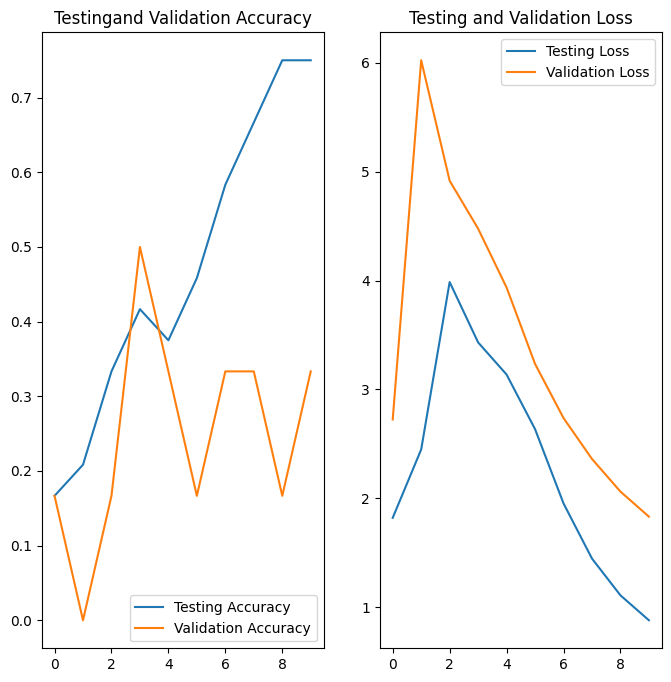

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Testing Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Testingand Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Testing Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Testing and Validation Loss')
plt.show()

In [ ]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(180, 180, 3),
    include_top=False)

In [ ]:
base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.
x = base_model(inputs)
# Convert features of shape `base_model.output_shape[1:]` to vectors
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
outputs = keras.layers.Dense(6)(x)
model = keras.Model(inputs, outputs)

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.1389 - loss: 9.6200 - val_accuracy: 0.2222 - val_loss: 12.0353
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.1458 - loss: 12.9739 - val_accuracy: 0.2778 - val_loss: 11.9372
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.1506 - loss: 12.6223 - val_accuracy: 0.2778 - val_loss: 10.2442
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.1740 - loss: 12.3805 - val_accuracy: 0.2778 - val_loss: 10.2350
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.1467 - loss: 12.7156 - val_accuracy: 0.2778 - val_loss: 11.0913
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1389 - loss: 12.8209 - val_accuracy: 0.2778 - val_loss: 11.9019
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.1701 - loss: 12.4430 - val_accuracy: 0.2778 - val_loss: 11.8334
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.1115 - loss: 13.4781 - val_accuracy: 0.2222 - val_loss: 1